# SpaceX S-1 — The valuation football field

The DCF put a single number on the equity. But for a company that is ~90% terminal value and tails — a
monopoly cash core, a launch franchise, and a money-losing AI furnace bolted together — *one* lens is the
weakest possible answer. This notebook triangulates the DCF with the methods that **contest** it, and draws
them on one chart as low–high ranges: a **football field**.

The point of a football field is not to manufacture a tidy consensus — it's to make **disagreement**
visible. So every bar here carries information the others don't:

| Method | Engine (independent of?) | What it answers |
|---|---|---|
| **DCF (floored + diluted)** | discounted cash flow (our `dcf.py`) | what the *cash flows* support |
| **SOTP on comps** | peer **market multiples**, by segment | what the *market* pays for each piece |
| **Real-option (AI)** | Bayesian `P × V` on the AI build | what the *option the DCF floors at \$0* is worth |
| **Private mark** | what buyers actually paid (reference line) | what the *market says today* |

> **The one-liner we expect it to make visible:** every method agrees the company is worth ~\$150–240B on
> Starlink + Space + a disciplined read of AI. The rest of the way to the ~\$350B private mark is an **AI
> option** the cash flows don't yet support. The disagreement between methods is, almost entirely, *how you
> value AI*.

**Provenance, loudly.** This is the only notebook that uses **non-S-1 data** (peer multiples, private
marks). Those inputs live in flagged CSVs (`csv/comps.csv`, `csv/market_marks.csv`), are date-stamped, and
are drawn **hatched/outlined** in every chart so you always know what is a filed fact and what is a market
opinion.

## Setup — load the DCF, the comps, and the assembled field

Everything computational lives in `analysis/valuation.py` (which imports `dcf.py` and the segment models),
so this notebook stays a narrated walkthrough. Net debt and the share count are the same S-1 inputs the DCF
uses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from analysis import charts, dcf, valuation as val

charts.apply_style()
COL = charts.SEGMENT_COLORS
SHARES = val.shares_m()
b2ps = lambda b: b * 1000.0 / SHARES        # equity $B -> $/share (pre-dilution)

A  = dcf.default_assumptions()
ff = val.football_field(A)

print(f"Pro-forma shares: {SHARES:,.0f}M   |   net debt (Mar-2026): ${val.net_debt_m()/1000:.1f}B\n")
disp = ff[["method", "low", "high", "point", "source_flag"]].copy()
disp["$/sh low"]  = b2ps(ff["low"])
disp["$/sh high"] = b2ps(ff["high"])
print("Football field — implied group equity ($B) and per share:")
print(disp.round(2).to_string(index=False))

Pro-forma shares: 12,520M   |   net debt (Mar-2026): $14.4B

Football field — implied group equity ($B) and per share:
                 method    low   high  point source_flag  $/sh low  $/sh high
DCF (floored + diluted)  54.77 224.45 144.11          s1      4.37      17.93
          SOTP on comps 102.60 235.59 169.10    external      8.19      18.82
       Real-option (AI) 159.11 240.61 199.86    external     12.71      19.22
Private mark (Dec-2024) 350.00 350.00 350.00    external     27.95      27.95


## Method 1 — DCF (the bar we're contesting)

The full build is in `notebooks/dcf.ipynb`; here we just lift its output. The DCF bar is the **scenario
range**: from the bear **abandonment floor** (shut the value-destroying AI build, keep Starlink — ≈ standalone
Starlink) up to the bull. The diamond is the **probability-weighted** blend (25/50/25), the single
option-like number that respects the floored downside and the fat-tailed upside.

This is the widest bar on the field, and honestly so: ~90% of a DCF this terminal-heavy is assumption, and
the bear/bull gap *is* the AI keep-vs-abandon decision priced out.

In [2]:
d = val.dcf_range(A)
print("DCF equity, abandonment-floored (SOTP) basis:")
for k in ["bear", "base", "bull"]:
    print(f"  {k.title():4}: ${d[k]/1000:6.1f}B   ({b2ps(d[k]/1000):5.2f}/sh)")
print(f"  prob-weighted (25/50/25): ${d['point']/1000:.1f}B   ({b2ps(d['point']/1000):.2f}/sh)")
print(f"  -> DCF bar: ${d['low']/1000:.0f}-{d['high']/1000:.0f}B")

DCF equity, abandonment-floored (SOTP) basis:
  Bear: $  54.8B   ( 4.37/sh)
  Base: $ 148.6B   (11.87/sh)
  Bull: $ 224.5B   (17.93/sh)
  prob-weighted (25/50/25): $144.1B   (11.51/sh)
  -> DCF bar: $55-224B


## Method 2 — Sum-of-the-parts on peer multiples (external)

A whole-company multiple is meaningless here (what is the "right" EV/EBITDA for a cash cow + a launch
monopoly + a money-losing AI furnace?). So we value each segment on **its own peer set's revenue multiple**
— a market engine genuinely independent of our cash flows — and add them up. Multiples are external
(`csv/comps.csv`, hatched below); the revenue they multiply is the S-1's FY2025 segment revenue.

- **Connectivity / Starlink — 6–10× revenue.** Mature cable/telecom trades ~2.5–4× sales (Charter 2.5×;
  Comcast 4.1× EBITDA); Starlink warrants a large premium for 30%+ growth, 60%+ gross margin, and a global
  near-monopoly — but is capped below pure software.
- **Space — 8–20× *customer* revenue.** Rocket Lab, the only public pure-play, trades ~16–64× revenue; we
  apply a deliberately conservative band. *Understated:* internal Starlink launches are unbooked
  (capitalized into Connectivity), so the launch franchise is bigger than its booked revenue.
- **AI — 5–17× revenue.** Public neoclouds (CoreWeave ~5× forward, Nebius ~17×). Note how *small* this is
  next to the xAI private mark (Method 4) — that gap is the whole argument.

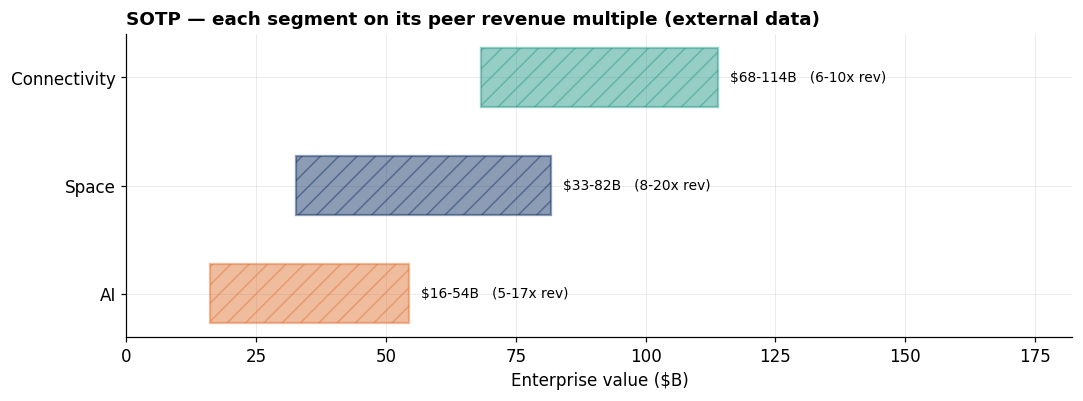

SOTP: EV $117-250B - net debt $14.4B = equity $103-236B ($8.19-18.82/sh)


In [3]:
s = val.sotp_comps()
tbl = s["table"]

fig, ax = plt.subplots(figsize=(10, 3.8))
segs = list(tbl.index); y = np.arange(len(segs))
for i, seg in enumerate(segs):
    lo, hi = tbl.loc[seg, "ev_low"]/1000, tbl.loc[seg, "ev_high"]/1000
    ax.barh(y[i], hi-lo, left=lo, height=0.55, color=COL[seg], alpha=0.5,
            hatch="//", edgecolor=COL[seg], linewidth=1.5, zorder=3)
    ax.annotate(f"${lo:.0f}-{hi:.0f}B   ({tbl.loc[seg,'mult_low']:.0f}-{tbl.loc[seg,'mult_high']:.0f}x rev)",
                (hi, y[i]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(segs); ax.invert_yaxis()
ax.set_xlabel("Enterprise value ($B)")
ax.set_xlim(0, tbl.ev_high.max()/1000 * 1.6)
ax.set_title("SOTP — each segment on its peer revenue multiple (external data)", loc="left", fontsize=12)
charts.finish(fig); charts.save(fig, "val_sotp_segments", layout=False); plt.show()

print(f"SOTP: EV ${s['ev_low']/1000:.0f}-{s['ev_high']/1000:.0f}B "
      f"- net debt ${s['net_debt']/1000:.1f}B = equity "
      f"${s['equity_low']/1000:.0f}-{s['equity_high']/1000:.0f}B "
      f"(${b2ps(s['equity_low']/1000):.2f}-{b2ps(s['equity_high']/1000):.2f}/sh)")

## Method 3 — Real-option on AI: pricing what the DCF floors at \$0

The DCF deliberately floors AI's terminal value at zero (the abandonment option: a fleet that can't cover
its own refresh simply isn't refreshed). That is the right *downside* treatment — but it throws away the
**upside**, which is the entire reason a rational owner keeps funding a −NPV segment. This bar puts that
upside back, as a Bayesian real option, and adds it to the part the DCF values confidently (Starlink + Space).

> **The frame (integrated §7).** With probability `P` the AI build clears its frontier (Grok/leasing
> economics work, the fleet covers refresh + power + R&D) and AI becomes a real franchise worth `payoff`;
> with probability `1 − P` you abandon it — already the DCF's \$0. So the option is worth `P × payoff`. We
> span a **skeptic-to-believer** `P` (15–40%) and a `payoff` from the DCF's own Bull AI *terminal* (~\$70B)
> up to the **standalone xAI private mark (~\$230B, Jan-2026 Series E)**. These are subjective inputs — so
> the bar is shown *wide*, and it is the one most sensitive to assumptions.

Starlink + Space DCF (Base) equity:     $   149B
AI option  P in [15%, 40%] x payoff [$70B, $230B]
  -> AI option value:                   $    10-92B
  -> total equity (Starlink+Space+opt): $   159-241B  ($12.7-19.2/sh)


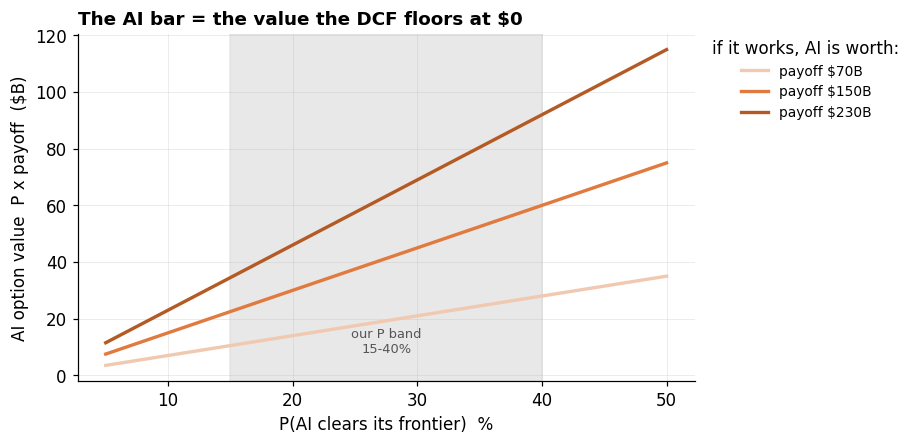

In [4]:
o  = val.AIOptionAssumptions()
ro = val.real_option_ai(A, o)
print(f"Starlink + Space DCF (Base) equity:     ${ro['base_equity']/1000:6.0f}B")
print(f"AI option  P in [{o.p_low:.0%}, {o.p_high:.0%}] x payoff "
      f"[${o.payoff_low_m/1000:.0f}B, ${o.payoff_high_m/1000:.0f}B]")
print(f"  -> AI option value:                   ${ro['ai_option_low']/1000:6.0f}-{ro['ai_option_high']/1000:.0f}B")
print(f"  -> total equity (Starlink+Space+opt): ${ro['low']/1000:6.0f}-{ro['high']/1000:.0f}B  "
      f"(${b2ps(ro['low']/1000):.1f}-{b2ps(ro['high']/1000):.1f}/sh)")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ps = np.linspace(0.05, 0.50, 60)
for pay, c in [(70, "#f0c9b0"), (150, "#e07a3f"), (230, "#b35a25")]:
    ax.plot(ps*100, ps*pay, color=c, lw=2.2, label=f"payoff ${pay}B")
ax.axvspan(o.p_low*100, o.p_high*100, color="0.85", alpha=0.6, zorder=0)
ax.annotate("our P band\n15-40%", ((o.p_low+o.p_high)/2*100, 8), ha="center", fontsize=8.5, color="#555")
ax.set_xlabel("P(AI clears its frontier)  %"); ax.set_ylabel("AI option value  P x payoff  ($B)")
ax.set_title("The AI bar = the value the DCF floors at $0", loc="left", fontsize=12)
charts.legend_outside(ax, fontsize=9, title="if it works, AI is worth:")
charts.finish(fig); charts.save(fig, "val_ai_option", layout=False); plt.show()

## Method 4 — The private mark (reference line, external)

Not a range — a dated line for "what buyers actually pay." We anchor on the **\$350B Dec-2024 employee
tender**, the conservative, well-established mark the DCF was built against (and, conveniently, ≈ our DCF
**bull**). Later 2025–26 figures (~\$800B tender, a ~\$1.25T SpaceX–xAI merger, a ~\$1.75T IPO target) exist
but are single-source / hype-blog grade — recorded with a `speculative` flag and shown only as a ceiling
annotation, never as the anchor. The **xAI Series E (~\$230B, Jan-2026)** is the solid standalone AI mark,
and it's what makes the real-option bar's upper end defensible.

In [5]:
marks = val.load_marks()
print(marks[["entity", "mark_usd_b", "as_of", "reliability", "note"]].to_string(index=False))
pm = val.private_mark_anchor_b()
print(f"\nAnchor (established): SpaceX ${pm:.0f}B  ({b2ps(pm):.2f}/sh)")

    entity  mark_usd_b   as_of reliability                                                                                                                                                                                                                                                                                                                note
    SpaceX         350 2024-12 established                                                                                                                                                                          Dec-2024 employee tender offer ~$350B. The conservative anchor the DCF was built against; used as the primary private-mark reference line.
    SpaceX         800 2025-12 speculative                                                                                                                                                                                                                             Reported Dec-2025 tender ~$800B. Si

## The field — assembled

Three method bars (DCF solid = S-1; SOTP and real-option hatched = external), the probability/midpoint as a
diamond, the convergence zone where **all three overlap** shaded, and the private mark as a dashed line. The
top axis converts equity \$B to \$/share (÷ 12,520M pro-forma).

Read it the way it's meant to be read: the bars **agree** on a broad ~\$160–240B middle (Starlink does the
heavy lifting in every method), and **disagree** only on how far above that the AI option carries you. The
private mark sits at the top of the field — it is a *bull-and-AI-works* price, not a fundamentals price.

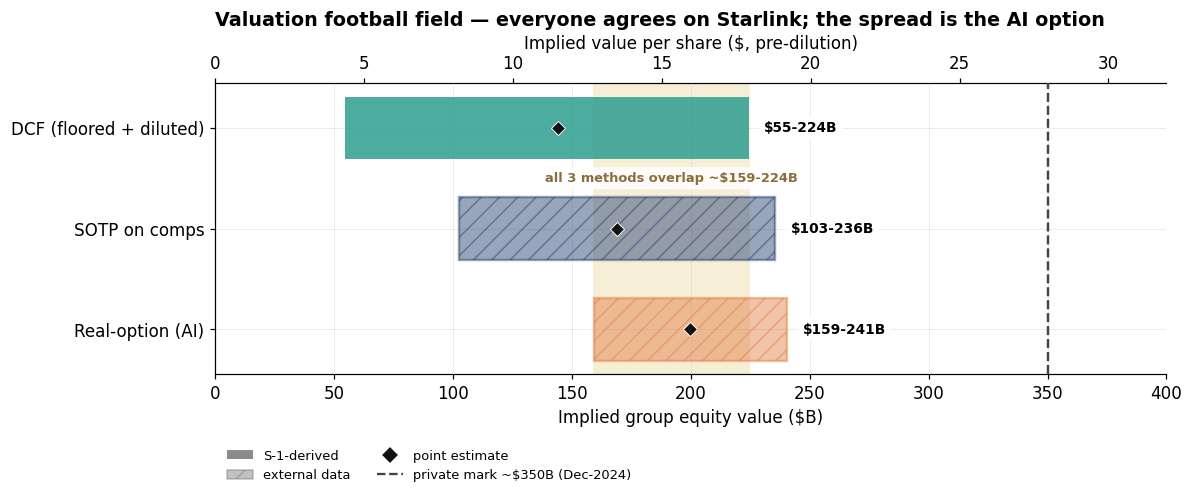

In [6]:
bars = ff[ff.method != "Private mark (Dec-2024)"].reset_index(drop=True)
pm = val.private_mark_anchor_b()
method_colors = {"DCF (floored + diluted)": COL["Connectivity"],
                 "SOTP on comps":           COL["Space"],
                 "Real-option (AI)":        COL["AI"]}
cols = [method_colors[m] for m in bars.method]

fig, ax = plt.subplots(figsize=(11, 4.8))
charts.hbar_range(bars, ax=ax, colors=cols, point="point")

# convergence zone = where all three bars overlap
zlo, zhi = bars.low.max(), bars.high.min()
ax.axvspan(zlo, zhi, color="#f4e7c8", alpha=0.7, zorder=0)
charts.annotate_clear(ax, f"all 3 methods overlap ~${zlo:.0f}-{zhi:.0f}B", ((zlo+zhi)/2, 0.5),
            ha="center", va="center", fontsize=8.5, color="#8a6d3b", fontweight="bold")

# private-mark reference line
ax.axvline(pm, color="#444", ls="--", lw=1.6, zorder=4)


# range labels (stagger if near private-mark line)
for i, r in bars.iterrows():
    dx = 10 if abs(r.high - pm) > 25 else -72
    ha = "left" if dx > 0 else "right"
    charts.annotate_clear(ax, f"${r.low:.0f}-{r.high:.0f}B", (r.high, i),
                          xytext=(dx, 0), textcoords="offset points",
                          va="center", ha=ha, fontsize=9, fontweight="bold")

ax.set_xlabel("Implied group equity value ($B)")
ax.set_xlim(0, 400)
sax = ax.secondary_xaxis("top", functions=(lambda b: b2ps(b), lambda p: p*SHARES/1000.0))
sax.set_xlabel("Implied value per share ($, pre-dilution)")
ax.set_title("Valuation football field — everyone agrees on Starlink; the spread is the AI option",
             loc="left", fontsize=12.5)
leg = [Patch(facecolor="#777", alpha=0.85, label="S-1-derived"),
       Patch(facecolor="#777", alpha=0.45, hatch="//", edgecolor="#777", label="external data"),
       Line2D([0], [0], marker="D", color="w", markerfacecolor="#111", markersize=8, label="point estimate"),
       Line2D([0], [0], color="#444", ls="--", label=f"private mark ~${pm:.0f}B (Dec-2024)")]
ax.legend(handles=leg,
          fontsize=8.5, loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.22)
charts.finish(fig); charts.save(fig, "valuation_field", layout=False); plt.show()

## Reverse-DCF — what the private mark is actually assuming

A football field begs the question the other way round: *what would you have to believe* for the \$350B mark
to be right? Not a bar — a diagnostic. Back the mark into an implied EV and divide by FY2025 revenue.

In [7]:
rev_fy25 = 18674.0  # FY2025 consolidated revenue ($M), S-1
ev_at_mark = pm*1000 + val.net_debt_m()      # $M
d = val.dcf_range(A)
print(f"Reverse-DCF on the ${pm:.0f}B private mark:")
print(f"  implied EV          = ${ev_at_mark/1000:.0f}B")
print(f"  / FY2025 revenue    = {ev_at_mark/rev_fy25:.1f}x   (revenue ${rev_fy25/1000:.1f}B)")
print(f"  our DCF bull equity = ${d['bull']/1000:.0f}B  ->  the mark is, essentially, the bull case")

Reverse-DCF on the $350B private mark:
  implied EV          = $364B
  / FY2025 revenue    = 19.5x   (revenue $18.7B)
  our DCF bull equity = $224B  ->  the mark is, essentially, the bull case


## Synthesis — where the methods agree, and where they don'\''t

**They agree on the floor and the middle.** Strip out the AI optionality and three independent engines —
discounted cash flow, peer multiples, and a Starlink+Space DCF — land in a broad **~$160–240B** band. That
convergence is real because it is mostly the *same asset*: Starlink, valued three different ways, keeps
coming out around $60–115B+ of equity (the DCF bull'\''s Connectivity is now the §7.7 **flywheel** — ARPU↓$38
/ ~64M subs / ~58% computed margin), and Space adds a modest, defensible launch-franchise layer. This is
the part of the number we'\''d defend in a fight.

**They disagree on AI, and only on AI.**
- **DCF** floors AI at $0 (it can'\''t cover its own refresh in bear/base) — so AI *subtracts* in the
  near term and contributes nothing in terminal unless the Bull frontier clears.
- **SOTP on comps** gives AI a disciplined $16–54B on neocloud revenue multiples.
- **The real-option** bar prices the *upside* the DCF discards — a `P × payoff` that, at believer settings,
  adds the most of any single input.
- **The private mark** (~$230B for xAI *alone*; ~$350B for the whole company) sits **above every method'\''s
  high** — even the real-option bar tops out near ~$240B. The market is paying for AI at a level no
  cash-flow or revenue-multiple method supports — i.e. it is buying the option, in size, today.

**So the football field'\''s verdict is a sentence:** on the S-1'\''s own numbers the company is worth ~$160–240B;
the ~$350B private mark prices *above even our most internally-consistent bull*, and the entire distance
from the convergence zone to the mark is the value of an AI bet the cash flows do not yet justify. That is
not a knock — it is the trade. A buyer at the mark is underwriting the AI option; a buyer at the convergence
zone is underwriting Starlink and getting the option for free.

**What we did not force.** No assumption was tuned to manufacture overlap; the bars disagree exactly where
the business is genuinely uncertain. **Deferred** (honestly flagged): the **replacement / asset floor**
(`valuation.replacement_value()` is a stub — needs defensible per-satellite + launch + spectrum costs),
cash taxes, and a tighter `P`/payoff calibration for the AI option. **External-data caveat:** comps and
marks are not S-1 facts; they are date-stamped, reliability-flagged, and quarantined in `csv/comps.csv` /
`csv/market_marks.csv`, and private valuations move fast — re-date them before the report ships.

## The \$1,000,000,000,000 question — reverse-engineering the hype

Every method above tops out around **\$224–243B**, and even the \$350B private mark sits *above* all of
them. Yet the IPO chatter is priced in **trillions** — and as of the **Feb-2026 SpaceX–xAI merger**, the
combined entity was marked **~\$1.25T = ~\$1.0T SpaceX + ~\$250B xAI** (`market_marks.csv`). So the "\$1T
SpaceX" isn't a hypothetical; it's a live mark. We are not going to *defend* it — we are going to **decompose
what you must believe to print it**, then say how silly (or not) each belief is.

The trick is a residual bridge in **EV space** (so net debt is bridged once). Value Starlink + Space at our
*own* — already generous — DCF **Bull**, and let the trillion fall out as a residual on the one segment the
cash flows can't pin down:

$$\text{AI EV}_{\text{required}} \;=\; \underbrace{(\$1{,}000\text{B} + \text{net debt})}_{\text{target EV}}
\;-\; \text{EV}_{\text{Connectivity}}^{\text{Bull}} \;-\; \text{EV}_{\text{Space}}^{\text{Bull}}$$

Giving the bull every non-AI benefit of the doubt makes the AI ask the *smallest* number consistent with
\$1T — and it is still enormous. Engine: `analysis/trillion.py` (imports `dcf.py`); the AI-lab marks are
external and quarantined in `csv/ai_labs.csv` — **refreshed via live web search (Jun-2026):** OpenAI ~\$852B,
Anthropic ~\$965B (now the most valuable AI startup, filed for IPO), xAI ~\$250B, Alphabet ~\$4.5T.

Reverse-engineering $1.0T equity  (Bull Starlink + Bull Space, our own DCF):
  Connectivity       $     208B
  Space              $      22B
  AI (required)      $     785B
  less: net debt     $     -14B
  = TARGET equity    $    1000B

  => the AI segment must be worth $785B
     that is 3.4x the ENTIRE non-AI business (Starlink $208B + Space at Bull),
     and 81x our own DCF Bull AI EV ($10B),
     and ~3.4x the standalone xAI Series-E mark (~$230B).


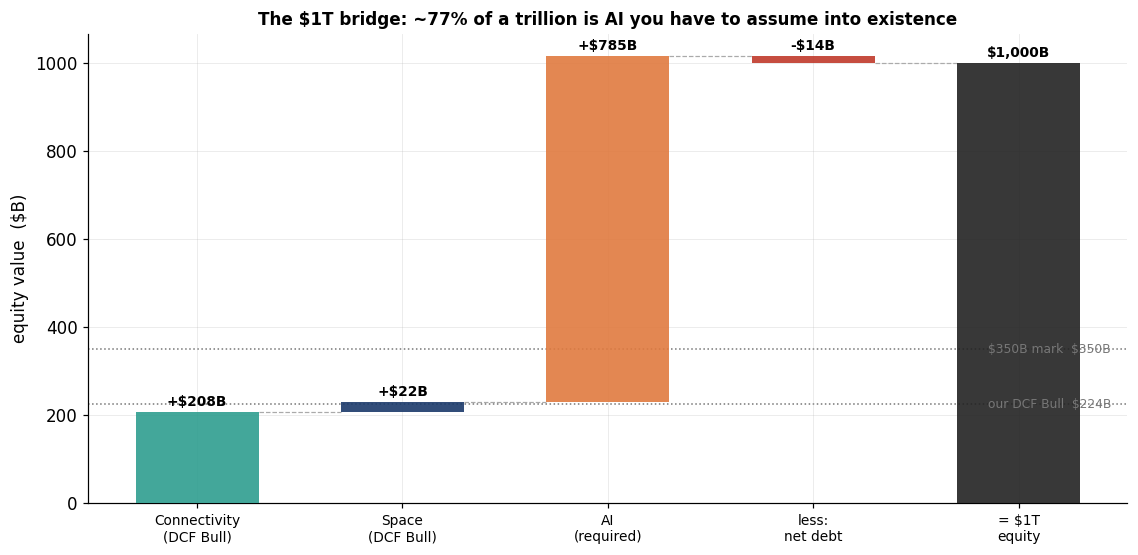

In [8]:
import analysis.trillion as tr
_d = lambda x: f"\\${x:,.0f}B"   # literal $ for matplotlib labels (escape mathtext)

TGT = 1000.0
br  = tr.bridge(TGT, conn_scn="Bull", space_scn="Bull")
comp = br["components_b"]
ai_req = br["ai_required_ev_b"]
BULL_AI_REV = dcf._ai("Bull").rev.iloc[-1]          # $M, the "believable" forward AI revenue line
dcf_bull_ai = dcf.value_scenario("Bull", A)["ev"]["AI"] / 1000

print(f"Reverse-engineering ${TGT/1000:.1f}T equity  (Bull Starlink + Bull Space, our own DCF):")
for k, v in comp.items():
    print(f"  {k:18} ${v:8.0f}B")
print(f"  {'= TARGET equity':18} ${TGT:8.0f}B")
print(f"\n  => the AI segment must be worth ${ai_req:.0f}B")
print(f"     that is {ai_req/(comp['Connectivity']+comp['Space']):.1f}x the ENTIRE non-AI business "
      f"(Starlink {_d(comp['Connectivity']).replace(chr(92),'')} + Space at Bull),")
print(f"     and {ai_req/dcf_bull_ai:.0f}x our own DCF Bull AI EV (${dcf_bull_ai:.0f}B),")
print(f"     and ~{ai_req/230:.1f}x the standalone xAI Series-E mark (~$230B).")

# --- waterfall: Connectivity -> +Space -> +AI(required) -> -net debt = $1T ----
labels = ["Connectivity\n(DCF Bull)", "Space\n(DCF Bull)", "AI\n(required)", "less:\nnet debt", "= $1T\nequity"]
vals   = [comp["Connectivity"], comp["Space"], comp["AI (required)"], comp["less: net debt"]]
cols   = [COL["Connectivity"], COL["Space"], COL["AI"], "#c0392b"]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
cum = 0.0
for i, (v, c) in enumerate(zip(vals, cols)):
    bottom = cum if v >= 0 else cum + v
    ax.bar(i, abs(v), bottom=bottom, color=c, alpha=0.9, width=0.6, zorder=3)
    ax.annotate(f"{'+' if v>=0 else '-'}{_d(abs(v))}", (i, bottom + abs(v)), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
    cum += v
    ax.plot([i + 0.3, i + 1 - 0.3], [cum, cum], color="#aaa", lw=0.8, ls="--", zorder=1)
ax.bar(len(labels) - 1, cum, color="#222", alpha=0.9, width=0.6, zorder=3)
ax.annotate(_d(cum), (len(labels) - 1, cum), xytext=(0, 4), textcoords="offset points",
            ha="center", fontsize=9, fontweight="bold")

for yv, lab in [(val.dcf_range(A)["bull"] / 1000, "our DCF Bull"),
                (val.private_mark_anchor_b(), "$350B mark")]:
    ax.axhline(yv, color="#777", ls=":", lw=1, zorder=1)
    ax.annotate(f"{lab}  {_d(yv)}", (4.45, yv), fontsize=8, color="#777", va="center", ha="right")

ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("equity value  (\\$B)")
ax.set_title("The \\$1T bridge: ~77% of a trillion is AI you have to assume into existence", fontsize=11)
charts.finish(fig); charts.save(fig, "trillion_bridge"); plt.show()

### The whole trillion is one segment — so what is SpaceX's AI worth?

The bridge isn't subtle: Starlink + Space at our **Bull** carry ~\$230B, and the remaining **~\$785B is AI**.
So "is SpaceX worth \$1T?" reduces to "is its AI — today a sub-scale lab doing ~\$3.2B of revenue — worth
~\$785B?" Put that next to what the market *actually* pays for AI in June 2026, and the comp you pick is the
entire answer (multiples below are EV/revenue on SpaceX's **Bull FY2030** AI revenue, ~\$71B):

- **Like Alphabet** (~10× — AI that works at planetary scale *and* prints ~\$440B of revenue): ~\$0.7T —
  *almost exactly the ask*, but only because Alphabet's multiple is low precisely because it is real and
  profitable.
- **Like a frontier lab** (Anthropic ~20×, OpenAI ~36× — multiples the market pays on *exploding but barely-
  profitable* revenue): **\$1.5–2.5T of AI alone**, blowing past the trillion without trying.

Here's the part that should stop you: **OpenAI (~\$852B on ~\$24B revenue) and Anthropic (~\$965B on ~\$47B
revenue) are each already worth ~\$1T by themselves.** A \$1T SpaceX values its **\$3.2B-revenue** AI segment
like a \$47B-revenue Anthropic — i.e. it asks you to believe xAI *is* a frontier lab, on ~1/15th the
revenue, and then staple a launch monopoly and a broadband utility on top for free.

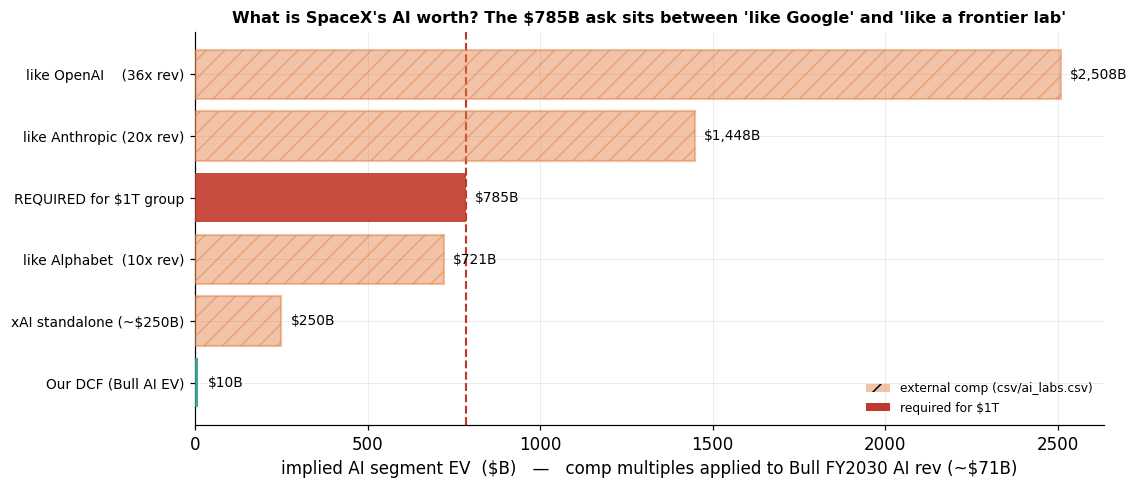

In [9]:
labs = tr.load_ai_labs()
fwd_m = BULL_AI_REV                          # $M
def _m(ent):
    return float(labs[labs.entity == ent].ev_rev_mult.iloc[0])
xai_v = float(labs[labs.entity == "xAI"].valuation_usd_b.iloc[0])

rows = [
    ("Our DCF (Bull AI EV)",                 dcf_bull_ai,                "s1"),
    (f"xAI standalone (~{_d(xai_v)})",       xai_v,                      "external"),
    (f"like Alphabet  ({_m('Alphabet'):.0f}x rev)",  _m("Alphabet")  * fwd_m/1000, "external"),
    ("REQUIRED for $1T group",               ai_req,                     "req"),
    (f"like Anthropic ({_m('Anthropic'):.0f}x rev)", _m("Anthropic") * fwd_m/1000, "external"),
    (f"like OpenAI    ({_m('OpenAI'):.0f}x rev)",    _m("OpenAI")    * fwd_m/1000, "external"),
]
rows.sort(key=lambda r: r[1])
y = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for i, (lab, v, flag) in enumerate(rows):
    c = "#c0392b" if flag == "req" else (COL["AI"] if flag == "external" else COL["Connectivity"])
    ax.barh(i, v, color=c, alpha=0.45 if flag == "external" else 0.9,
            hatch="//" if flag == "external" else None, edgecolor=c,
            linewidth=1.4 if flag == "external" else 0, zorder=3)
    ax.annotate(_d(v), (v, i), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
ax.axvline(ai_req, color="#c0392b", ls="--", lw=1.4, zorder=2)
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel("implied AI segment EV  (\\$B)   —   comp multiples applied to Bull FY2030 AI rev (~\\$71B)")
ax.set_title("What is SpaceX's AI worth? The \\$785B ask sits between 'like Google' and 'like a frontier lab'",
             fontsize=10.5)
ax.legend(handles=[Patch(facecolor=COL["AI"], alpha=0.45, hatch="//", label="external comp (csv/ai_labs.csv)"),
                   Patch(facecolor="#c0392b", label="required for $1T")],
          loc="lower right", fontsize=8, frameon=False)
charts.finish(fig); charts.save(fig, "trillion_ai_worth"); plt.show()

### The honest way: AGI is a lottery ticket, and \$785B is the price of the bet

A frontier-lab multiple isn't really a multiple — it's a **probability-weighted payoff** wearing a multiple's
clothes. Nobody pays 38× revenue for the cash; they pay it for the tail where the lab *wins* transformative
AI and the franchise is worth trillions. So the cleaner way to price the AI ask is the same Bayesian
real-option frame as Method 3, just sized for the moon:

$$\text{AI value} \;=\; P(\text{xAI wins a transformative-AI franchise}) \times V(\text{franchise if it wins})$$

Set that equal to the required \$785B and the (P, V) pairs the \$1T crowd is implicitly underwriting fall
straight out. The curves below are iso-payoff lines; the dashed red line is the AI ask. Where they cross is
the **break-even probability** — the odds you must assign to xAI becoming a multi-trillion-dollar AGI winner
for \$1T to be fair value.

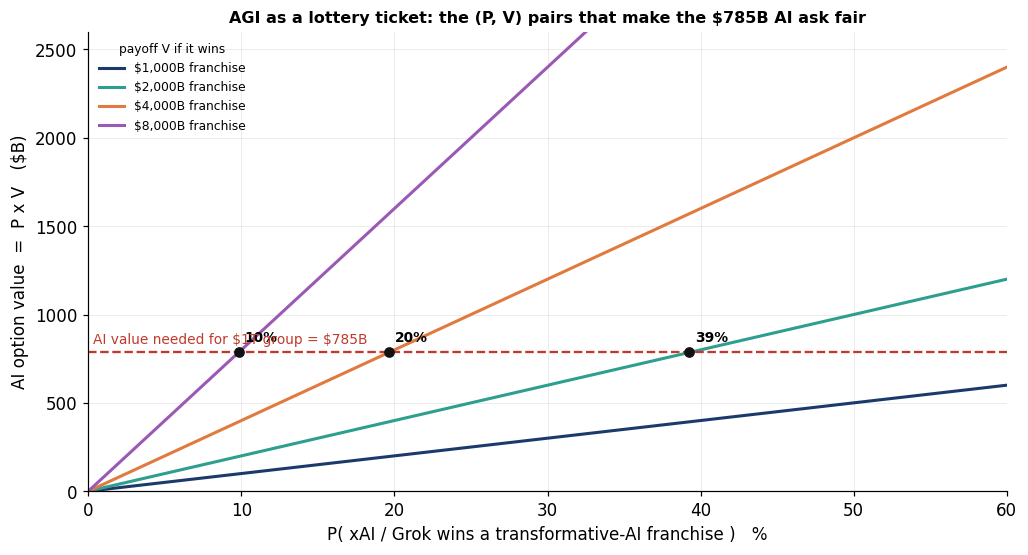

Break-even AGI odds implied by the $1T ask:
  if winning is worth $1T  ->  you must assign P = 79%
  if winning is worth $2T  ->  you must assign P = 39%
  if winning is worth $4T  ->  you must assign P = 20%
  if winning is worth $8T  ->  you must assign P = 10%


In [10]:
P = np.linspace(0, 0.6, 200)
payoffs_b = [1000, 2000, 4000, 8000]     # $B value of the won franchise
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for v, c in zip(payoffs_b, charts.PALETTE):
    ax.plot(P * 100, P * v, lw=2, color=c, label=f"{_d(v)} franchise")
    pb = ai_req / v
    if pb <= 0.6:
        ax.scatter(pb * 100, ai_req, color="#111", zorder=5, s=36)
        ax.annotate(f"{pb:.0%}", (pb * 100, ai_req), xytext=(4, 7),
                    textcoords="offset points", fontsize=9, fontweight="bold")
ax.axhline(ai_req, color="#c0392b", ls="--", lw=1.5, zorder=2)
ax.annotate(f"AI value needed for \\$1T group = {_d(ai_req)}", (0.3, ai_req),
            xytext=(0, 6), textcoords="offset points", fontsize=9, color="#c0392b")
ax.set_xlabel("P( xAI / Grok wins a transformative-AI franchise )   %")
ax.set_ylabel("AI option value  =  P x V   (\\$B)")
ax.set_ylim(0, 2600); ax.set_xlim(0, 60)
ax.legend(title="payoff V if it wins", fontsize=8, title_fontsize=8, loc="upper left")
ax.set_title("AGI as a lottery ticket: the (P, V) pairs that make the \\$785B AI ask fair", fontsize=10.5)
charts.finish(fig); charts.save(fig, "trillion_agi_pv"); plt.show()

print("Break-even AGI odds implied by the $1T ask:")
for v in payoffs_b:
    print(f"  if winning is worth ${v/1000:.0f}T  ->  you must assign P = {ai_req/v:.0%}")

### Reversed Bayesian — price the *same* \$10T AGI lottery across every lab

Method 3 asked "what P×V justifies SpaceX's AI?". Now flip it into a cross-lab test. Fix one transformative-AI
prize — call it **\$10T** (a stand-in for the AGI/automation TAM if a lab "wins") — treat every frontier lab
as a ticket on that same prize, and read its **market valuation as an implied probability**. But do it
*fairly*: each lab is also a real, growing business even if AGI never lands, so we first credit a **no-AGI
floor** (a conservative ~12× revenue run-rate) and call only the **residual** the AGI bet:

$$P_{\text{AGI}} \;=\; \frac{\text{valuation} \;-\; \underbrace{12\times\text{revenue}}_{\text{no-AGI business}}}{\$10\text{T}}$$

With the June-2026 marks (OpenAI \$852B on ~\$24B rev; Anthropic \$965B on ~\$47B rev; xAI \$250B on ~\$0.5B),
the AGI-tail odds you are actually paying come out below. The bar's **dark** part is that irreducible AGI bet;
the **light** part is what current revenue already justifies.

                   entity  valuation_b  runrate_b  val_per_rev  p_pure  p_floor
                      xAI        250.0        0.5        500.0   0.025    0.024
                Anthropic        965.0       47.0         21.0   0.096    0.040
                   OpenAI        852.0       24.0         36.0   0.085    0.056
SpaceX·AI (implied @ $1T)        785.0        3.2        245.0   0.079    0.075


<>:14: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:14: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/tmp/claude-501/ipykernel_48854/906221308.py:14: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  _rr = f"\${r.runrate_b:.1f}B" if r.runrate_b < 1 else _d(r.runrate_b)


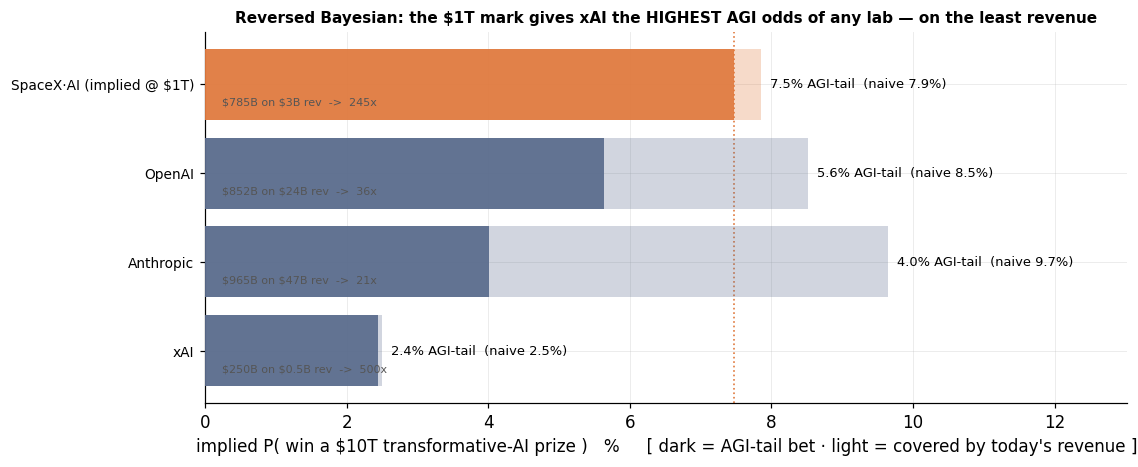


The tell: SpaceX-AI's fair (revenue-adjusted) AGI odds 7.5% EXCEED Anthropic's 4.0% and OpenAI's 5.6%,
and ~3x what xAI's own standalone $250B round implies (2.4%) — you pay frontier-winner odds for the smallest horse.


In [11]:
lt = tr.agi_lottery_table(prize_b=10_000.0, floor_mult=12.0)
lt = lt.sort_values("p_floor").reset_index(drop=True)
print(lt[["entity", "valuation_b", "runrate_b", "val_per_rev", "p_pure", "p_floor"]]
      .round({"valuation_b": 0, "runrate_b": 1, "val_per_rev": 0, "p_pure": 3, "p_floor": 3}).to_string(index=False))

y = np.arange(len(lt))
fig, ax = plt.subplots(figsize=(10.5, 4.4))
for i, r in lt.iterrows():
    base = COL["AI"] if r.kind == "spacex" else "#5a6b8c"
    ax.barh(i, r.p_floor * 100, color=base, alpha=0.95, zorder=3)                       # irreducible AGI tail
    ax.barh(i, (r.p_pure - r.p_floor) * 100, left=r.p_floor * 100, color=base, alpha=0.28, zorder=3)  # revenue-covered
    ax.annotate(f"{r.p_floor*100:.1f}% AGI-tail  (naive {r.p_pure*100:.1f}%)",
                (r.p_pure * 100, i), xytext=(6, 0), textcoords="offset points", va="center", fontsize=8.5)
    _rr = f"\${r.runrate_b:.1f}B" if r.runrate_b < 1 else _d(r.runrate_b)
    ax.annotate(f"{_d(r.valuation_b)} on {_rr} rev  ->  {r.val_per_rev:.0f}x",
                (0.15, i), xytext=(4, -12), textcoords="offset points", va="center", fontsize=7.3, color="#555")
sx = lt[lt.kind == "spacex"].iloc[0]
ax.axvline(sx.p_floor * 100, color=COL["AI"], ls=":", lw=1.1, zorder=1)
ax.set_yticks(y); ax.set_yticklabels(lt.entity, fontsize=9)
ax.set_xlabel("implied P( win a \\$10T transformative-AI prize )   %     [ dark = AGI-tail bet · light = covered by today's revenue ]")
ax.set_xlim(0, max(lt.p_pure) * 100 * 1.35)
ax.set_title("Reversed Bayesian: the \\$1T mark gives xAI the HIGHEST AGI odds of any lab — on the least revenue",
             fontsize=10)
charts.finish(fig); charts.save(fig, "trillion_agi_lottery"); plt.show()

print(f"\nThe tell: SpaceX-AI's fair (revenue-adjusted) AGI odds {sx.p_floor:.1%} EXCEED Anthropic's "
      f"{lt[lt.entity=='Anthropic'].p_floor.iloc[0]:.1%} and OpenAI's {lt[lt.entity=='OpenAI'].p_floor.iloc[0]:.1%},")
print(f"and ~3x what xAI's own standalone $250B round implies "
      f"({lt[lt.entity=='xAI'].p_floor.iloc[0]:.1%}) — you pay frontier-winner odds for the smallest horse.")

### The hard way: what the *cash flows* would actually have to do

Multiples and probabilities are easy to assert. The third route asks the un-fun question: for the AI segment
to be worth \$785B on **discounted cash flow** — our own engine, no comp, no lottery — how far past the Bull
do the physical dials have to go? We crank `dcf`'s exact AI levers (nameplate GW, utilization, \$/GPU-hr,
chip life) into a **super-bull** and read off the segment EV. The number that matters is the *mature* free
cash flow the terminal value capitalizes: ~**\$121B/yr**.

Below, AI EV vs 2030 nameplate. It crosses \$785B at roughly **~17 GW** — which, decoded, is ~10 million
GPUs, **~\$370B of cumulative build capex**, ~17 GW of *continuous* power draw (on the order of the entire
SpaceX-scale grid you'd have to build), at 88% utilization and \$3.5/GPU-hr held for a decade. The cash path
to \$1T isn't a spreadsheet assumption; it's a national-infrastructure program that happens to clear its cost
of capital.

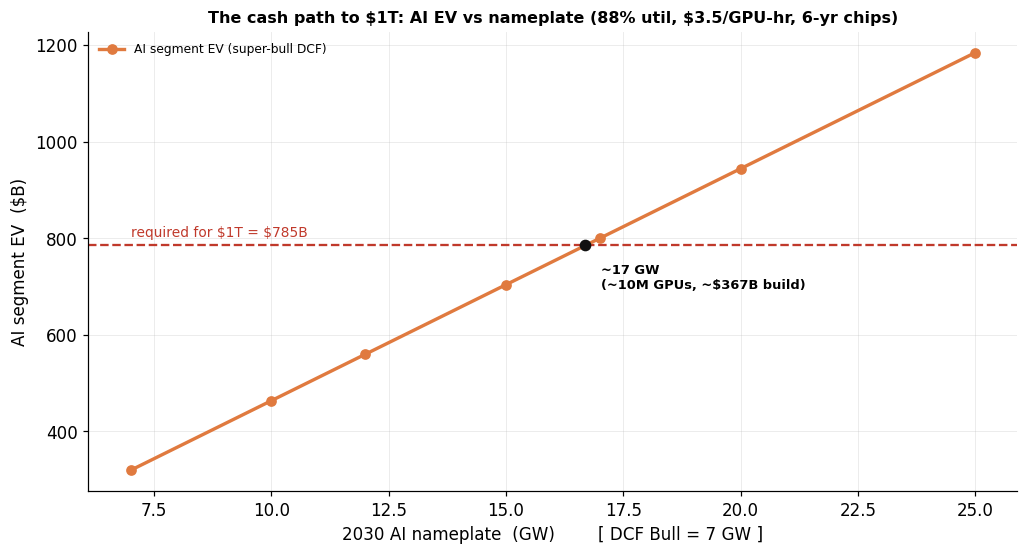

Super-bull AI EV by nameplate GW:
   7 GW -> AI EV $  319B  (FY2030 AI rev $ 115B, mature FCF $  53B/yr)
  10 GW -> AI EV $  464B  (FY2030 AI rev $ 164B, mature FCF $  76B/yr)
  12 GW -> AI EV $  560B  (FY2030 AI rev $ 196B, mature FCF $  92B/yr)
  15 GW -> AI EV $  704B  (FY2030 AI rev $ 245B, mature FCF $ 116B/yr)
  17 GW -> AI EV $  800B  (FY2030 AI rev $ 277B, mature FCF $ 132B/yr)
  20 GW -> AI EV $  944B  (FY2030 AI rev $ 326B, mature FCF $ 156B/yr)
  25 GW -> AI EV $ 1184B  (FY2030 AI rev $ 407B, mature FCF $ 196B/yr)


In [12]:
gws = [7, 10, 12, 15, 17, 20, 25]
evs, revs, fcfs = [], [], []
for gw in gws:
    r = tr.super_bull_ai_ev(tr.AISuperBull(gw=gw, util=0.88, price=3.5))
    evs.append(r["ev"] / 1000); revs.append(r["fwd_rev_2030"] / 1000); fcfs.append(r["mature_fcf"] / 1000)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(gws, evs, "-o", color=COL["AI"], lw=2.2, zorder=3, label="AI segment EV (super-bull DCF)")
ax.axhline(ai_req, color="#c0392b", ls="--", lw=1.5, zorder=2)
ax.annotate(f"required for \\$1T = {_d(ai_req)}", (7, ai_req), xytext=(0, 6),
            textcoords="offset points", fontsize=9, color="#c0392b")
# crossing marker (linear interp between bracketing GW points)
import numpy as _np
gx = float(_np.interp(ai_req, evs, gws))
ax.scatter(gx, ai_req, color="#111", zorder=5, s=44)
ax.annotate(f"~{gx:.0f} GW\n(~{gx*0.6:.0f}M GPUs, ~\\${gx*22:.0f}B build)", (gx, ai_req),
            xytext=(10, -28), textcoords="offset points", fontsize=8.5, fontweight="bold")
ax.set_xlabel("2030 AI nameplate  (GW)        [ DCF Bull = 7 GW ]")
ax.set_ylabel("AI segment EV  (\\$B)")
ax.set_title("The cash path to \\$1T: AI EV vs nameplate (88% util, \\$3.5/GPU-hr, 6-yr chips)", fontsize=10.5)
ax.legend(fontsize=8, loc="upper left")
charts.finish(fig); charts.save(fig, "trillion_cash_path"); plt.show()

print("Super-bull AI EV by nameplate GW:")
for gw, ev, rev, fcf in zip(gws, evs, revs, fcfs):
    print(f"  {gw:2d} GW -> AI EV ${ev:5.0f}B  (FY2030 AI rev ${rev:4.0f}B, mature FCF ${fcf:4.0f}B/yr)")

### Expanding the infrastructure story — the bull that doesn't need to *win* AGI

The lottery framing assumes you must **win** AGI. But notice what the super-bull DCF actually prices: not a
model that wins, a **fleet that rents**. It throws cash whether or not anyone reaches AGI — you just have to
*build, power, and fill* the compute. That makes the infra-bull the more defensible route to \$785B (cash
flows, not a coin flip) — but it swaps one impossible thing for another. Below, the full **(scale × price)
frontier**: AI EV over nameplate GW and blended \$/GPU-hr; the dashed line is the \$785B the \$1T mark needs.

Then decode what a point on that line *is*. A GW of GPUs isn't a spreadsheet cell — it's silicon, capex and
**power**. At the ~17 GW that clears the ask, the bull owes you ~**10 million GPUs**, ~**\$370B of cumulative
build capex**, and ~**23 GW of facility power — on the order of two dozen nuclear reactors, ~2% of total US
generating capacity** — running at 88% utilization and \$3.5/GPU-hr for a decade. And the revenue that
supports it (~\$280B/yr) is **larger than OpenAI's and Anthropic's *combined* current run-rates**. The
infra-bull doesn't ask you to win a coin flip; it asks you to build a national-scale utility and keep it full.

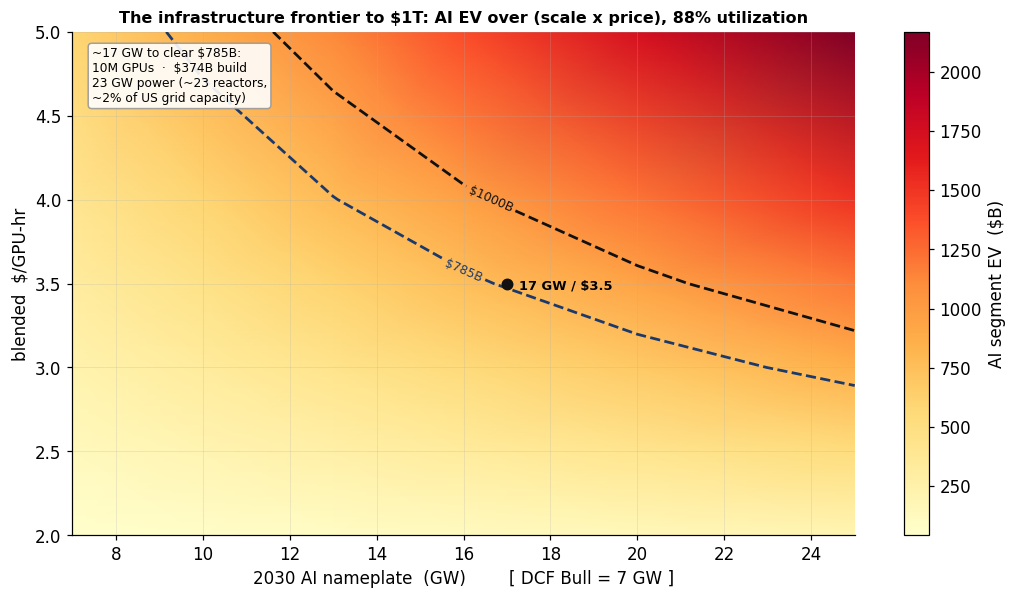

Physical decode of the cash path (facility power at PUE 1.35):
   7 GW IT ->  4.2M GPUs | $154B build |    9 GW power (~9 reactors, 0.8% of US capacity)
  12 GW IT ->  7.2M GPUs | $264B build |   16 GW power (~16 reactors, 1.4% of US capacity)
  17 GW IT -> 10.2M GPUs | $374B build |   23 GW power (~23 reactors, 1.9% of US capacity)
  25 GW IT -> 15.0M GPUs | $550B build |   34 GW power (~34 reactors, 2.8% of US capacity)


In [13]:
gws    = [7, 10, 13, 16, 20, 25]
prices = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
grid = tr.super_bull_ev_grid(gws, prices, util=0.88)
G, Pr = np.meshgrid(gws, prices)
Z = grid.values

fig, ax = plt.subplots(figsize=(9.8, 5.6))
pcm = ax.pcolormesh(G, Pr, Z, cmap="YlOrRd", shading="gouraud", zorder=1)
cs = ax.contour(G, Pr, Z, levels=[ai_req, 1000], colors=["#1b3a6b", "#111"],
                linewidths=1.8, linestyles="--", zorder=2)
ax.clabel(cs, fmt=lambda v: f"\\${v:.0f}B", fontsize=8)
cb = fig.colorbar(pcm, ax=ax); cb.set_label("AI segment EV  (\\$B)")
ax.scatter([17], [3.5], color="#111", s=46, zorder=5)
ax.annotate("17 GW / \\$3.5", (17, 3.5), xytext=(8, -4), textcoords="offset points",
            fontsize=8.5, fontweight="bold")

dec = tr.infra_decode(17)
txt = (f"~17 GW to clear {_d(ai_req)}:\n"
       f"{dec['gpus_m']:.0f}M GPUs  ·  {_d(dec['build_capex_b'])} build\n"
       f"{dec['facility_power_gw']:.0f} GW power (~{dec['reactor_equiv']:.0f} reactors,\n"
       f"~{dec['pct_us_capacity']:.0%} of US grid capacity)")
ax.text(0.025, 0.97, txt, transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round", fc="white", ec="#999", alpha=0.9), zorder=6)

ax.set_xlabel("2030 AI nameplate  (GW)        [ DCF Bull = 7 GW ]")
ax.set_ylabel("blended  \\$/GPU-hr")
ax.set_title("The infrastructure frontier to \\$1T: AI EV over (scale x price), 88% utilization", fontsize=10.5)
charts.finish(fig); charts.save(fig, "trillion_infra_grid"); plt.show()

print("Physical decode of the cash path (facility power at PUE 1.35):")
for gw in [7, 12, 17, 25]:
    d = tr.infra_decode(gw)
    print(f"  {gw:2d} GW IT -> {d['gpus_m']:4.1f}M GPUs | ${d['build_capex_b']:3.0f}B build | "
          f"{d['facility_power_gw']:4.0f} GW power (~{d['reactor_equiv']:.0f} reactors, "
          f"{d['pct_us_capacity']:.1%} of US capacity)")

### Verdict — the trillion is internally consistent and externally feverish

Put the routes side by side and they say the **same thing in different accents**: \$1T is ~\$230B of business
we can defend plus **~\$785B of pure AI conviction**. The June-2026 data doesn't debunk that — it *sharpens*
it, because the frontier labs have run so far that the comparison is now apples-to-apples:

- **Comps:** trivially clearable — OpenAI (~\$852B) and Anthropic (~\$965B) are each already ~\$1T *by
  themselves*. Granting SpaceX's AI a frontier multiple (20–36×) on its Bull revenue prints \$1.5–2.5T. The
  catch is unchanged: those multiples sit on \$24–47B of real revenue; SpaceX's AI has **\$3.2B**.
- **Reversed Bayesian:** the sharpest finding. On a common \$10T AGI prize, after crediting each lab's no-AGI
  business, the \$1T mark implies xAI has a **~7.5% shot at winning AGI — *higher* than Anthropic (~4%) or
  OpenAI (~6%), and ~3× what xAI's own \$250B round implies (~2.4%)**. You are paying frontier-*winner* odds
  for the lab with the least revenue and the latest start.
- **Cash flows (the infra-bull):** the one that doesn't need a coin flip — but needs a **~17 GW, ~\$370B-capex,
  ~10M-GPU, ~23-reactor** machine humming at 88% utilization for a decade, earning ~\$280B/yr (more than
  OpenAI + Anthropic combined sell today). Defensible as arithmetic; staggering as a build.

So can you get to \$1T? Yes — and the model shows exactly how: **take the Bull on Starlink and Space, then
value the AI segment as a frontier lab / a ~1-in-13 AGI lottery ticket / a 17 GW compute utility.** Each is a
thing *someone* credibly believes. What is **not** honest is calling the sum a \$1T *valuation* of a rockets-
and-broadband company. It is a Bull-case Starlink, plus a launch monopoly, plus a **multi-hundred-billion-
dollar venture bet that the third-place AI lab wins** — priced as if it already has. The cash flows say
~\$150–240B; the private market pays ~\$350B for the option; the trillion is the AGI tail, marked to perfection.

> **Provenance.** Frontier-lab marks (`csv/ai_labs.csv`) refreshed via live web search, June 2026 (OpenAI
> \$852B / Anthropic \$965B / xAI \$250B / Alphabet ~\$4.5T), with sources. The bridge logic is robust to their
> exact level — it's a residual on our own DCF — so only the comp-multiple and lottery cross-checks move if the
> marks age. Re-pull before quoting.